# Logistic Regression from Scratch

Binary classification using a single neuron — no frameworks, just NumPy.

**Architecture:** `X → Z = W·X + b → A = sigmoid(Z) → Loss`

Applied to the Cat vs Non-Cat dataset.

In [1]:
import numpy as np
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

## Load Data

Cat vs Non-Cat dataset — 209 training examples, 50 test examples.  
Each image is 64×64 RGB, flattened to a vector of 12,288 features.

In [2]:
def load_data():
    """Loads the cat vs non-cat dataset. Searches for datasets/ folder automatically."""
    
    search_dir = Path().resolve()
    for _ in range(3):
        datasets_path = search_dir / 'datasets'
        if datasets_path.exists():
            break
        search_dir = search_dir.parent
    
    train = h5py.File(datasets_path / 'train_catvnoncat.h5', 'r')
    test  = h5py.File(datasets_path / 'test_catvnoncat.h5', 'r')
    
    X_train = np.array(train['train_set_x']) / 255.0
    y_train = np.array(train['train_set_y']).reshape(1, -1)
    
    X_test  = np.array(test['test_set_x']) / 255.0
    y_test  = np.array(test['test_set_y']).reshape(1, -1)
    
    # Flatten images: (m, 64, 64, 3) → (12288, m)
    X_train = X_train.reshape(X_train.shape[0], -1).T
    X_test  = X_test.reshape(X_test.shape[0], -1).T
    
    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape:  {X_test.shape}")
    print(f"y_test shape:  {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_data()

X_train shape: (12288, 209)
y_train shape: (1, 209)
X_test shape:  (12288, 50)
y_test shape:  (1, 50)


## Core Functions

### Forward Propagation
```
Z = W.T · X + b
A = sigmoid(Z)
Loss = -1/m * sum(Y*log(A) + (1-Y)*log(1-A))
```

### Backward Propagation
```
dZ = A - Y          (shortcut from chain rule: dL/dA * dA/dZ)
dW = X · dZ.T / m
db = sum(dZ) / m
```

In [3]:
def sigmoid(z):
    """Applies sigmoid activation elementwise. Output is between 0 and 1."""
    return 1 / (1 + np.exp(-z))


def initialize_with_zeros(dim):
    """Initializes weights to zero and bias to 0.0"""
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b


def propagate(X, y, w, b):
    """Forward pass + backward pass. Returns gradients and loss."""
    
    m = X.shape[1]

    # Forward pass
    z = np.dot(w.T, X) + b
    A = sigmoid(z)
    loss = -np.sum(y * np.log(A) + (1 - y) * np.log(1 - A)) / m

    # Backward pass
    # dZ = A - Y  (chain rule shortcut for sigmoid + cross entropy)
    dw = np.dot(X, (A - y).T) / m
    db = np.sum(A - y) / m

    gradients = {"dw": dw, "db": db}
    
    return gradients, loss


def optimize(X, y, w, b, learning_rate, iterations, print_cost):
    """Gradient descent loop. Updates weights and bias over iterations."""
    
    costs = []

    for i in range(iterations):

        gradients, loss = propagate(X, y, w, b)
        costs.append(loss)

        dw = gradients['dw']
        db = gradients['db']

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if print_cost and i % 100 == 0:
            print(f"Iteration {i:4d}: Loss = {loss:.6f}")

    parameters = {"w": w, "b": b}
    return parameters, costs


def predict(X, parameters):
    """Runs forward pass and thresholds at 0.5 to get binary predictions."""
    
    w, b = parameters['w'], parameters['b']
    A = sigmoid(np.dot(w.T, X) + b)
    return (A > 0.5).astype(int)


def model(X_train, y_train, learning_rate=0.01, iterations=1000, print_cost=False):
    """Ties everything together. Initializes, trains, and returns learned parameters."""
    
    w, b = initialize_with_zeros(X_train.shape[0])
    parameters, costs = optimize(X_train, y_train, w, b, learning_rate, iterations, print_cost)
    return parameters, costs

## Train the Model

In [4]:
parameters, costs = model(X_train, y_train, learning_rate=0.005, iterations=2000, print_cost=True)

Iteration    0: Loss = 0.693147
Iteration  100: Loss = 0.584508
Iteration  200: Loss = 0.466949
Iteration  300: Loss = 0.376007
Iteration  400: Loss = 0.331463
Iteration  500: Loss = 0.303273
Iteration  600: Loss = 0.279880
Iteration  700: Loss = 0.260042
Iteration  800: Loss = 0.242941
Iteration  900: Loss = 0.228004
Iteration 1000: Loss = 0.214820
Iteration 1100: Loss = 0.203078
Iteration 1200: Loss = 0.192544
Iteration 1300: Loss = 0.183033
Iteration 1400: Loss = 0.174399
Iteration 1500: Loss = 0.166521
Iteration 1600: Loss = 0.159305
Iteration 1700: Loss = 0.152667
Iteration 1800: Loss = 0.146542
Iteration 1900: Loss = 0.140872


## Evaluate Results

In [5]:
def evaluate(y_true, y_pred, name=""):
    """Prints accuracy, precision, recall, F1, and confusion matrix."""
    
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    acc       = 100 - np.mean(np.abs(y_pred - y_true)) * 100
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Non-Cat  Cat")
    print(f"Actual Non-Cat  [{tn:^7}  {fp:^7}]")
    print(f"Actual Cat      [{fn:^7}  {tp:^7}]")


y_pred_train = predict(X_train, parameters)
y_pred_test  = predict(X_test, parameters)

evaluate(y_train, y_pred_train, "Train")
evaluate(y_test,  y_pred_test,  "Test")


--- Train ---
Accuracy:  99.04%
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  136       1   ]
Actual Cat      [   1       71   ]

--- Test ---
Accuracy:  70.00%
Precision: 0.8214
Recall:    0.6970
F1 Score:  0.7541

Confusion Matrix:
                 Predicted
                 Non-Cat  Cat
Actual Non-Cat  [  12        5   ]
Actual Cat      [  10       23   ]


## Training Cost Curve

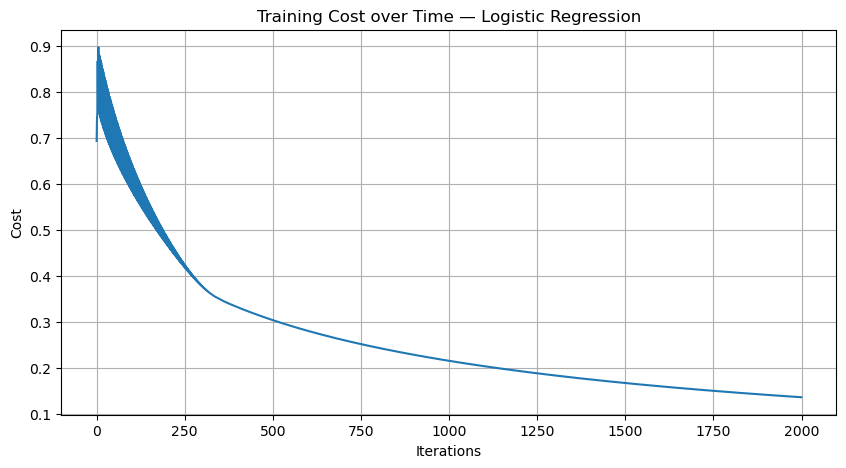

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations')
plt.title('Training Cost over Time — Logistic Regression')
plt.grid(True)
plt.show()

## Observations

- **Train accuracy ~99%, Test accuracy ~70%** — classic overfitting
- The model memorizes training examples but doesn't generalize well
- Logistic regression draws a **single linear decision boundary** — not powerful enough for image data
- Flattening a 64×64 image loses all spatial information — the same cat in a different position becomes a completely different input

→ This motivates adding hidden layers: **Shallow Neural Network**